# Linear Classifier on MNIST Dataset

In this notebook we will see a bunch of algorithms working on MNIST dataset.
This dataset is composed of $70,000$ single channels images ( $1 \times 28 \times 28$ pixels), representing the 10 numbers ($[0-9]$)

In order to avoid problems regarding memory issues, we will practically use a different version of this dataset, available at *sklearn* library, which consist of $\approx 1800$ images $8\times 8$

![alt_text](https://storage.googleapis.com/tfds-data/visualization/fig/mnist-3.0.1.png)

In [5]:
import numpy as np
# import all needed modules
import pandas as pd
import seaborn as sns

from scipy.special import softmax

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

### LET'S GET THE DATASET

In [6]:
mnist = load_digits()
mnist

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

In [ ]:
images = mnist['images'] 
target = mnist['target']
images.shape, target.shape  # X, y

((1797, 8, 8), (1797,))

<Figure size 640x480 with 0 Axes>

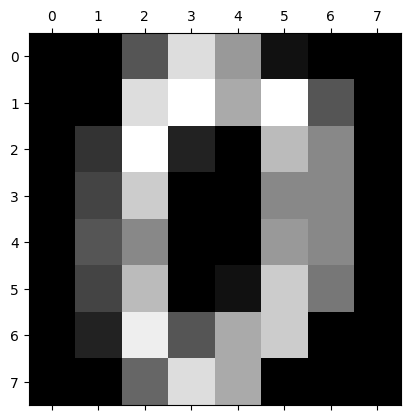

In [8]:
plt.gray()
plt.matshow(images[0])

### NOW LET'S SEE HOW THE DATA IS DISTRIBUTED IN A MULTI-DIMENSIONAL SPACE
Since we have $64$ features, we cannot use all of them to see the data distribution, also because the data is not represented by a bunch of feature vectors, but each data point is an image, therefore it is a matrix. So, in this case, we first **flatten** the images in order to get a feature vector, than we will perform a **PCA** to extract the first two principal components, which will be used to have a plot.

In [14]:
from skimage.transform import resize
flattened_mnist = resize(images, (1797, 32,32)).reshape(1797, 32*32)
pca = PCA(n_components = 0.8)
decomposed_mnist = pca.fit_transform(flattened_mnist)
decomposed_mnist

array([[-1.77935095e+01,  3.99827189e+01,  5.53685793e+01, ...,
        -6.46478892e+00, -1.57624300e+01, -7.15243547e+00],
       [ 2.58761134e+01, -5.59488018e+01, -3.63456179e+01, ...,
        -1.24630510e+01, -1.13640481e+01,  2.77132225e+00],
       [ 1.47286802e+01, -2.92055003e+01, -2.14580825e+01, ...,
        -4.15751031e+01,  1.72904383e+01,  2.53146192e+01],
       ...,
       [ 4.42761448e+01, -2.47145013e+01, -2.46334827e+01, ...,
         2.33544868e+01,  1.69365928e+01,  9.88605447e+00],
       [-3.20552149e+01,  9.31500868e+00,  4.12801233e+01, ...,
         2.15026028e+01,  1.08432400e+01,  2.61478576e+01],
       [ 2.14876148e+01,  2.81672000e+01, -1.86859859e+01, ...,
         3.55063111e+01,  2.52165359e+01, -6.59645504e-03]],
      shape=(1797, 10))

In [15]:
decomposed_mnist = decomposed_mnist[:, :2]
decomposed_mnist

array([[-17.79350945,  39.98271894],
       [ 25.87611336, -55.94880175],
       [ 14.72868016, -29.20550032],
       ...,
       [ 44.2761448 , -24.71450133],
       [-32.05521488,   9.31500868],
       [ 21.48761478,  28.16720005]], shape=(1797, 2))

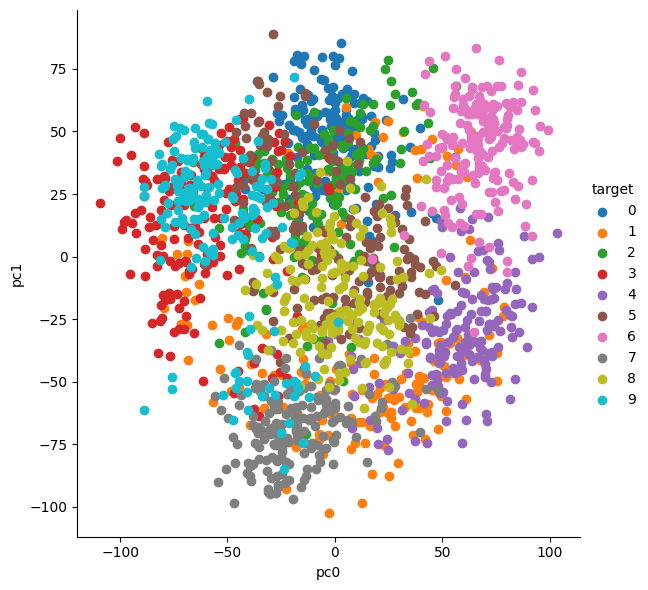

In [16]:
data_to_plot = pd.DataFrame(decomposed_mnist, columns=['pc0', 'pc1'])
data_to_plot['target'] = target
sns.FacetGrid(data_to_plot, hue='target', height=6).map(plt.scatter, 'pc0', 'pc1').add_legend()

Once we have seen our data, we can prepare our setting, in order to solve the classification task, testing multiple alorithms.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(flattened_mnist, target,
                                                    stratify=target,
                                                    random_state=41,
                                                    shuffle=True)


### FIRST TEST
**Model**: SGDClassifier. This is a linear model,so the outcome is expressed as

Given an input datapoint $x \in \mathbb{R}^{d}$ and <br> its respective output class vector $y \in \{0,1\}^{k}$, where $k = #classes$

$$\hat{y} = \mathbf{W}x+b$$
where:
$\mathbf{W} \in \mathbb{R}^{k \times d}$<br> are the hyperplane parameters of the classifier
$b \in \mathbb{R}^k$ is the intercept

In [18]:
model = SGDClassifier(loss='log_loss',
                      penalty='l1',
                      random_state=42)

model.fit(X_train, y_train)

print(f'W \in {model.coef_.shape}')
print(f'b \in {model.intercept_.shape}')

<>:7: SyntaxWarning: invalid escape sequence '\i'
<>:8: SyntaxWarning: invalid escape sequence '\i'
<>:7: SyntaxWarning: invalid escape sequence '\i'
<>:8: SyntaxWarning: invalid escape sequence '\i'
C:\Users\fonta\AppData\Local\Temp\ipykernel_22904\1406503193.py:7: SyntaxWarning: invalid escape sequence '\i'
  print(f'W \in {model.coef_.shape}')
C:\Users\fonta\AppData\Local\Temp\ipykernel_22904\1406503193.py:8: SyntaxWarning: invalid escape sequence '\i'
  print(f'b \in {model.intercept_.shape}')


W \in (10, 1024)
b \in (10,)


But how is represented a single prediction?

<li> Take a data point, for example, the first image in the test set

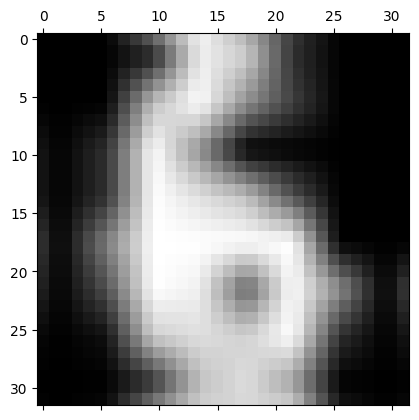

In [19]:
plt.matshow(X_test[0].reshape((32, 32)))

<li> See what the model predicts for us

In [20]:
model.predict(X_test[[0]])

array([6])

But what exactly is a single prediction?

**Recap**: $f(x) = \mathbf{W}x+b$

In [21]:
np.matmul(model.coef_, X_test[0]) + model.intercept_

array([-439213.98344232, -458260.12009891, -637909.42136606,
       -368106.14450326, -172541.17221037, -233342.51496411,
        110385.89465414, -555818.36600417,  -61346.27993477,
       -526455.29291734])

These are not probabilities.
How to convert this vector in a probability one?

**Softmax function**.
This is a *squashing function*, which takes as input a given vector and returns the probability vector associated, which means that it respects **Kolmogorov axioms**

$$softmax(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{n}{e^{x_j}}}$$

In [22]:
softmax(np.matmul(model.coef_, X_test[0]) + model.intercept_)

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

Now let's evaluate our model

In [23]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'accuracy on test set: {accuracy:.4f}')

accuracy on test set: 0.9511


Basing the results on a single model can be misleading. We need to have strong results to say with high confidence that the task is solved with the best means

In [24]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# compare other basic classifiers on the same data
models = []

#K-NN
models.append(('KNN with 5 neighbors', KNeighborsClassifier(n_neighbors=5)))

#linear classifier with cross-entropy loss
models.append(('SGD with cross-entropy loss', SGDClassifier(loss='log_loss', penalty='l2', alpha=0.001)))

#linear classifier with hinge loss (SVM)
models.append(('SGD with hinge loss', SGDClassifier(loss='hinge', penalty='l2', alpha=0.001)))

models.append(('SVM', SVC(C=10, random_state=42)))

print('Accuracy on test set\n')
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'{name:<30}: {accuracy:.4f}')

Accuracy on test set

KNN with 5 neighbors          : 0.9844


c:\Users\fonta\Desktop\Uni\Repo\ComputerVision\env\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\fonta\Desktop\Uni\Repo\ComputerVision\env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.752.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundati

SGD with cross-entropy loss   : 0.9333
SGD with hinge loss           : 0.9378
SVM                           : 0.9822


To smooth the performances, we'd better perform a cross validation, in order to have a more robust model

In [25]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=10)

for name, model in models:
    cv_scores = cross_val_score(model, flattened_mnist, target, cv=kf)
    print(f'{name:<30}: m={cv_scores.mean():.4f}, sd={cv_scores.std():.4f}')

KNN with 5 neighbors          : m=0.9711, sd=0.0183
SGD with cross-entropy loss   : m=0.9132, sd=0.0360
SGD with hinge loss           : m=0.9232, sd=0.0404
SVM                           : m=0.9766, sd=0.0191
